# H2 — Mental-model Accuracy / Explicability (F1 / F2 / F3)

OpenMATB transparency study (content-constant, *wording-only* design). This
notebook covers **only hypothesis H2** — one half of the load-bearing H1/H2 pair:

> **H2 (contrastive form improves explicability).** Post-block mental-model
> accuracy is highest under the contrastive forms **F2 / F3**, even though the
> information content is identical across forms.

H2 is the **objective** counterpart to H1: where H1 asks whether the verbose form
*feels* more transparent (subjective explainability), H2 asks whether the
operator's mental model actually *updated* (objective explicability). The study's
core claim is that these move in **opposite** directions — F1 feels most
informative, yet F2/F3 leave the operator better calibrated.

**Design**

| Role | Variable | Detail |
|------|----------|--------|
| Independent variable | Explanation **form** | F1 verbose · F2 contrastive · F3 contrastive + actionable. **Within-subjects** — each participant sees all three (Latin-square counterbalanced), each paired with a different gauge set (A/B/C) so the probe cannot be answered from another block. |
| Primary DV | **Explicability composite** | `mm_explicability` ∈ [0, 1], the proportion of all probe items answered correctly. Higher = better-calibrated mental model. |
| Sub-scores | act · miss · close | `mm_act_accuracy` (did the aid act on X?), `mm_miss_accuracy` (did it fail to act on Y?), `mm_close_accuracy` (was there a close call on Z?). All **higher = better**. |

## How H2 is measured (the 3-question mental-model probe)

After each block — *before* the subjective items, to capture the model before
reflection contaminates it — three `genericscales` sliders probe the operator's
mental model. Each block, the aid **handles** one of its two active gauges (acts
on it; both near-misses land here) and **misses** the other (its only events are
the two unhandled failures), giving each active gauge one clean role. Every item
is a **yes/no question about one active gauge**, scored **offline against that
block's roles**:

- **`act`** — "Did the aid act on **X**?" Truth = X is the handled gauge. → `mm_act_accuracy`.
- **`miss`** — "Did the aid **fail to act** on **Y**?" Truth = Y is the missed gauge. → `mm_miss_accuracy`.
- **`close`** — "Was there a **close call** (near miss) on **Z**?" Truth = Z is the handled gauge. → `mm_close_accuracy`.

The act and miss questions always name *different* gauges, and which gauge each
question targets is **counterbalanced across blocks** so no fixed yes/no answer
pattern beats actually having tracked the block.

We report **descriptive statistics and visualisations**.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table
from matb_analysis.discovery import find_study_sessions, DEFAULT_SESSIONS_DIR
from matb_analysis.validation import validate_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
FORM_LABELS = {"F1": "F1\nverbose", "F2": "F2\ncontrastive", "F3": "F3\n+actionable"}
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)

# Read the curated study sessions from session_logs/. Whichever candidate
# directory actually contains study sessions is used, so this runs unchanged
# as real participants are collected.
CANDIDATES = [Path.cwd().parent / "session_logs", DEFAULT_SESSIONS_DIR]
DATA_DIR = next((d for d in CANDIDATES if find_study_sessions(d)), CANDIDATES[0])

## 1. Load the sessions and build the H2 metrics table

`find_study_sessions()` reads every study session under `DATA_DIR`. Each session
contributes three rows (one per form). The mental-model metrics are produced by
`build_metrics_table()`, which scores the three probe sliders against each block's
ground truth.

In [2]:
sessions = find_study_sessions(DATA_DIR)
print(f"Reading logs from: {DATA_DIR}")
print(f"Discovered {len(sessions)} study session(s).")

table = build_metrics_table(sessions)
H2_COLS = ["mm_explicability", "mm_act_accuracy", "mm_miss_accuracy", "mm_close_accuracy"]
(table[["participant", "form", "block"] + H2_COLS]
    .sort_values(["participant", "form"]).reset_index(drop=True))

Reading logs from: c:\Projects\HumanCenteredAI\Analysis\session_logs
Discovered 6 study session(s).


,participant,form,block,mm_explicability,mm_act_accuracy,mm_miss_accuracy,mm_close_accuracy
0,P01,F1,A,0.666667,0.0,1.0,1.0
1,P01,F2,B,1.000000,1.0,1.0,1.0
2,P01,F3,C,1.000000,1.0,1.0,1.0
3,P02,F1,A,0.666667,1.0,1.0,0.0
4,P02,F2,C,1.000000,1.0,1.0,1.0
5,P02,F3,B,1.000000,1.0,1.0,1.0
6,P03,F1,B,1.000000,1.0,1.0,1.0
7,P03,F2,A,0.666667,1.0,1.0,0.0
8,P03,F3,C,0.666667,0.0,1.0,1.0
9,P04,F1,C,0.666667,1.0,1.0,0.0


### 1b. Sanity check: design realised as intended

Each session is cross-checked against the Latin-square design (form ↔ block order,
panel form vs. briefing). Every participant should contribute exactly one block per
form, so that each form is probed against all three gauge sets equally across the
cohort. Any `ok = False` row must be resolved before trusting that session.

In [3]:
report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with design issues.")

print(f"\nParticipants: {table['participant'].nunique()}")
print("Blocks per form (should be equal):")
print(table["form"].value_counts().reindex(FORM_ORDER).to_string())
print("\nform x gauge-set (counterbalancing):")
print(pd.crosstab(table["form"], table["block"]).reindex(FORM_ORDER).to_string())

6 session(s) validated; 0 with design issues.

Participants: 6
Blocks per form (should be equal):
form
F1    6
F2    6
F3    6

form x gauge-set (counterbalancing):
block  A  B  C
form          
F1     2  2  2
F2     2  2  2
F3     2  2  2


## 2. Primary DV — explicability composite by form

Descriptive statistics of `mm_explicability` (the [0, 1] composite, higher = a
more accurate mental model) for each form. H2 predicts the contrastive forms
**F2 / F3** to sit **above** the verbose form F1.

In [4]:
def describe(df, col):
    g = df.groupby("form")[col]
    out = pd.DataFrame({
        "n_blocks": g.size(),
        "mean": g.mean(),
        "sd": g.std(),
        "median": g.median(),
        "min": g.min(),
        "max": g.max(),
    }).reindex(FORM_ORDER).round(3)
    return out

describe(table, "mm_explicability")

,n_blocks,mean,sd,median,min,max
form,,,,,,
F1,6,0.722,0.136,0.667,0.667,1.0
F2,6,0.833,0.279,1.000,0.333,1.0
F3,6,0.889,0.172,1.000,0.667,1.0


**Figure 1 — distribution of the explicability composite by form.** Box = median
and interquartile range; whiskers = range; each dot is one block. H2 predicts the
F2/F3 distributions to sit above F1 (higher = better-calibrated mental model).

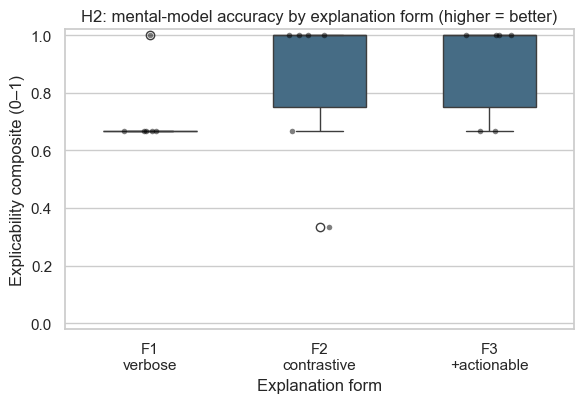

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.boxplot(data=table, x="form", y="mm_explicability", order=FORM_ORDER,
            color="#3b6e8f", width=0.55, ax=ax)
sns.stripplot(data=table, x="form", y="mm_explicability", order=FORM_ORDER,
              color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Explicability composite (0–1)")
ax.set_xticks(range(len(FORM_ORDER)))
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_title("H2: mental-model accuracy by explanation form (higher = better)")
fig.tight_layout()
fig.savefig(OUT / "h2_explicability_by_form.png", dpi=150)
plt.show()

**Figure 2 — within-subject view.** Each grey line is one participant across the
three forms; the thick line is the mean. Because the design is within-subjects,
this shows whether *individuals* tend to build a more accurate model under F2/F3,
not just the group average.

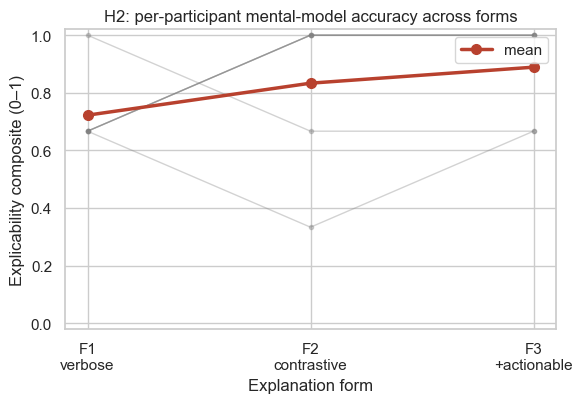

In [6]:
wide = table.pivot_table(index="participant", columns="form", values="mm_explicability")
wide = wide.reindex(columns=FORM_ORDER)

fig, ax = plt.subplots(figsize=(6, 4.2))
x = np.arange(len(FORM_ORDER))
for _, row in wide.iterrows():
    ax.plot(x, row.values, color="grey", alpha=0.35, marker="o", markersize=3,
            linewidth=1)
ax.plot(x, wide.mean(axis=0).values, color="#b8412e", marker="o", markersize=7,
        linewidth=2.5, label="mean")
ax.set_xticks(x)
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Explicability composite (0–1)")
ax.set_title("H2: per-participant mental-model accuracy across forms")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "h2_explicability_perparticipant.png", dpi=150)
plt.show()

## 3. Unpacking the composite — the three question types

The composite pools three yes/no questions per block. This section reports each
separately so an effect can be traced to its source — knowing which gauge the aid
**worked** (`act`), which it **abandoned** (`miss`), and where the **close call**
occurred (`close`):

- `mm_act_accuracy` — "did the aid act on X?" (**higher = better**).
- `mm_miss_accuracy` — "did the aid fail to act on Y?" (**higher = better**).
- `mm_close_accuracy` — "was there a close call on Z?" (**higher = better**).

Each is one item per block, so a form's score is the share of blocks answered
correctly. H2 predicts F2/F3 above F1 on all three.

In [7]:
SUBSCORES = ["mm_act_accuracy", "mm_miss_accuracy", "mm_close_accuracy"]
parts_desc = (table.groupby("form")[SUBSCORES]
                   .agg(["mean", "median", "std"])
                   .reindex(FORM_ORDER)
                   .round(3))
parts_desc

mm_act_accuracy               mm_miss_accuracy              \
                mean median    std             mean median  std   
form                                                              
F1             0.500    0.5  0.548              1.0    1.0  0.0   
F2             0.833    1.0  0.408              1.0    1.0  0.0   
F3             0.667    1.0  0.516              1.0    1.0  0.0   

     mm_close_accuracy                
                  mean median    std  
form                                  
F1               0.667    1.0  0.516  
F2               0.667    1.0  0.516  
F3               1.000    1.0  0.000

**Figure 3 — the three sub-scores by form.** All **higher = better**. H2 predicts
F2/F3 to sit **above** F1 on each — the contrastive panel makes the aid's
per-gauge behaviour easier to read off and remember.

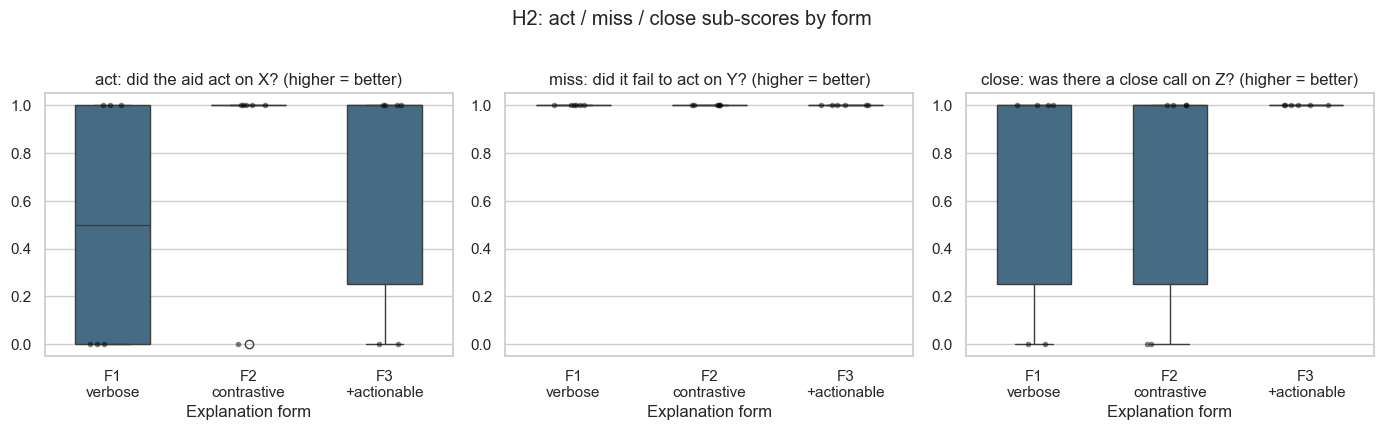

In [8]:
panels = [
    ("mm_act_accuracy", "act: did the aid act on X? (higher = better)"),
    ("mm_miss_accuracy", "miss: did it fail to act on Y? (higher = better)"),
    ("mm_close_accuracy", "close: was there a close call on Z? (higher = better)"),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (col, title) in zip(axes, panels):
    sns.boxplot(data=table, x="form", y=col, order=FORM_ORDER,
                color="#3b6e8f", width=0.55, ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER,
                  color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Explanation form")
    ax.set_ylabel("")
    ax.set_xticks(range(len(FORM_ORDER)))
    ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
    ax.set_title(title)
fig.suptitle("H2: act / miss / close sub-scores by form", y=1.02)
fig.tight_layout()
fig.savefig(OUT / "h2_mentalmodel_by_form.png", dpi=150)
plt.show()

## 4. Compact summary table

One row per form, suitable for the report. H2 predicts the explicability composite
and all three sub-scores (act, miss, close) to **rise** from F1 to F2/F3.

In [9]:
SUMMARY_COLS = ["mm_explicability", "mm_act_accuracy", "mm_miss_accuracy", "mm_close_accuracy"]
summary = (table.groupby("form")[SUMMARY_COLS]
              .agg(["mean", "median", "std"])
              .reindex(FORM_ORDER)
              .round(3))
summary.to_csv(OUT / "h2_mental_model_summary_by_form.csv")
summary

mm_explicability               mm_act_accuracy                \
                 mean median    std            mean median    std   
form                                                                
F1              0.722  0.667  0.136           0.500    0.5  0.548   
F2              0.833  1.000  0.279           0.833    1.0  0.408   
F3              0.889  1.000  0.172           0.667    1.0  0.516   

     mm_miss_accuracy             mm_close_accuracy                
                 mean median  std              mean median    std  
form                                                               
F1                1.0    1.0  0.0             0.667    1.0  0.516  
F2                1.0    1.0  0.0             0.667    1.0  0.516  
F3                1.0    1.0  0.0             1.000    1.0  0.000